In [ ]:
!pip install optuna torch torchvision scikit-learn sentence-transformers groq -qprint('✓ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 14.6 MB/s eta 0:00:00
✓ Done!


In [ ]:
import os, re, json, time, warningsimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport torchimport torch.nn as nnimport torch.optim as optimfrom torchvision import datasets, transformsfrom torch.utils.data import DataLoader, Subsetimport optunafrom sklearn.model_selection import train_test_splitfrom sklearn.metrics import accuracy_scorefrom sentence_transformers import SentenceTransformerfrom sklearn.metrics.pairwise import cosine_similarityfrom groq import Groqwarnings.filterwarnings('ignore')optuna.logging.set_verbosity(optuna.logging.WARNING)device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')print(f'✓ Device: {device}')

✓ Device: cpu


In [ ]:
from google.colab import filesprint('Upload your 7 CSV files!')uploaded = files.upload()print(f'✓ Uploaded: {list(uploaded.keys())}')

Upload your 7 CSV files!


Saving EImage.csv to EImage.csv
Saving EText.csv to EText.csv
Saving ETabular.csv to ETabular.csv
Saving EAudio.csv to EAudio.csv
Saving EVideo.csv to EVideo.csv
Saving EGraph.csv to EGraph.csv
Saving ETime-Series.csv to ETime-Series.csv
✓ Uploaded: ['EImage.csv', 'EText.csv', 'ETabular.csv', 'EAudio.csv', 'EVideo.csv', 'EGraph.csv', 'ETime-Series.csv']


In [ ]:
def parse_num(val):    try:        s = str(val).replace(',', '').strip()        if '-' in s:            p = s.split('-')            return float((float(p[0]) + float(p[1])) / 2)        return float(s)    except:        return np.nandfs = []for fname in uploaded.keys():    if fname.endswith('.csv'):        df = pd.read_csv(fname)        df.columns = df.columns.str.strip()        df['source_file'] = fname        dfs.append(df)        print(f'  ✓ {fname}: {len(df)} rows')df_all = pd.concat(dfs, ignore_index=True)df_all['Batch Size Clean'] = df_all['Batch Size'].apply(parse_num)df_all['LR Clean']         = df_all['Learning Rate'].apply(parse_num)df_all['Train Clean']      = df_all['Train'].apply(parse_num)df_all = df_all.dropna(subset=['Data Modality','Downstream Task',                                'Best Models','Batch Size Clean','LR Clean'])df_all = df_all.reset_index(drop=True)print(f'\n✓ Total clean rows: {len(df_all)}')train_df, test_df = train_test_split(    df_all, test_size=0.2, random_state=42)train_df = train_df.reset_index(drop=True)test_df  = test_df.reset_index(drop=True)print(f'✓ Train: {len(train_df)} rows (80%) ← Agent will learn from here')print(f'✓ Test : {len(test_df)} rows (20%) ← UNSEEN DATA')

  ✓ EImage.csv: 500 rows
  ✓ EText.csv: 270 rows
  ✓ ETabular.csv: 265 rows
  ✓ EAudio.csv: 260 rows
  ✓ EVideo.csv: 255 rows
  ✓ EGraph.csv: 230 rows
  ✓ ETime-Series.csv: 220 rows

✓ Total clean rows: 1776
✓ Train: 1420 rows (80%) ← Agent শিখবে এখান থেকে
✓ Test : 356 rows (20%) ← UNSEEN DATA


In [ ]:
def make_text(row):    return f"{row.get('Data Modality','')} {row.get('Downstream Task','')} {row.get('Features','')} train:{row.get('Train Clean','')}"print('Building embeddings from TRAIN data only...')emb_model        = SentenceTransformer('all-MiniLM-L6-v2')train_texts      = train_df.apply(make_text, axis=1).tolist()train_embeddings = emb_model.encode(train_texts, show_progress_bar=True, convert_to_numpy=True)print(f'✓ Embeddings shape: {train_embeddings.shape}')print('✓ Agent ready! (only saw train data)')

Building embeddings from TRAIN data only...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/45 [00:00<?, ?it/s]

✓ Embeddings shape: (1420, 384)
✓ Agent ready! (শুধু train data দেখেছে)


In [ ]:
GROQ_API_KEY = 'Your API Key'os.environ['GROQ_API_KEY'] = GROQ_API_KEYgroq_client = Groq(api_key=GROQ_API_KEY)print('✓ Groq ready!')

✓ Groq ready!


In [ ]:
def find_similar(query_row, top_k=5):    """Finds similar rows from TRAIN data - never sees test data"""    q_emb = emb_model.encode([make_text(query_row)])    sims  = cosine_similarity(q_emb, train_embeddings)[0]    idx   = np.argsort(sims)[::-1][:top_k]    sim_df = train_df.iloc[idx].copy()    sim_df['similarity'] = sims[idx]    return sim_dfdef retrieval_agent(query_row, top_k=5):    sim = find_similar(query_row, top_k)    return {        'model':      sim['Best Models'].mode()[0],        'batch_size': int(sim['Batch Size Clean'].median()),        'lr':         float(sim['LR Clean'].median()),        'metric':     sim['Evaluation Metric'].mode()[0],        'method':     'retrieval'    }def llm_agent(query_row, top_k=5):    sim     = find_similar(query_row, top_k)    context = ''    for _, r in sim.head(3).iterrows():        context += f"- {r['Dataset Name']}: Model={r['Best Models']}, Batch={r['Batch Size']}, LR={r['Learning Rate']}, Metric={r['Evaluation Metric']}\n"    prompt = f"""You are an ML expert. Recommend hyperparameters.Query:- Modality: {query_row.get('Data Modality')}- Task: {query_row.get('Downstream Task')}- Features: {query_row.get('Features')}Similar datasets:{context}Respond ONLY in JSON:{{"model": "...", "batch_size": number, "lr": number, "metric": "..."}}"""    try:        resp  = groq_client.chat.completions.create(            model='llama-3.1-8b-instant',            messages=[{'role':'user','content':prompt}],            temperature=0.3, max_tokens=200        )        text  = resp.choices[0].message.content.strip()        match = re.search(r'\{.*\}', text, re.DOTALL)        if match:            rec = json.loads(match.group())            rec['method'] = 'llm'            return rec    except Exception as e:        print(f'  LLM error: {e}')    return retrieval_agent(query_row, top_k)  # fallbackdef hybrid_agent(query_row, top_k=5):    ret = retrieval_agent(query_row, top_k)    llm = llm_agent(query_row, top_k)    return {        'model':      llm['model'],       # LLM chooses good model        'batch_size': ret['batch_size'],  # Retrieval chooses good batch        'lr':         ret['lr'],        'metric':     ret['metric'],        'method':     'hybrid'    }def meta_learning_agent(query_row, top_k=20):    """    Extracts global patterns from all train data and recommends    Uses modality-level statistics instead of specific similarity    """    modality = str(query_row.get('Data Modality', '')).lower().strip()    # Get all train rows of same modality    mask = train_df['Data Modality'].str.lower().str.strip().str.contains(        modality.split()[0] if modality else 'image', na=False    )    modal_df = train_df[mask] if mask.sum() >= 5 else train_df    # Global pattern: most common model, median batch/lr    recommended_model  = modal_df['Best Models'].mode()[0]    recommended_batch  = int(modal_df['Batch Size Clean'].median())    recommended_lr     = float(modal_df['LR Clean'].median())    recommended_metric = modal_df['Evaluation Metric'].mode()[0]    # Task-level refinement    task = str(query_row.get('Downstream Task', '')).lower()    task_mask = modal_df['Downstream Task'].str.lower().str.contains(        task.split()[0] if task else '', na=False    )    if task_mask.sum() >= 3:        task_df = modal_df[task_mask]        recommended_model  = task_df['Best Models'].mode()[0]        recommended_batch  = int(task_df['Batch Size Clean'].median())        recommended_lr     = float(task_df['LR Clean'].median())        recommended_metric = task_df['Evaluation Metric'].mode()[0]    return {        'model':      recommended_model,        'batch_size': recommended_batch,        'lr':         recommended_lr,        'metric':     recommended_metric,        'method':     'meta_learning'    }print('✓ Meta-Learning agent added!')print('✓ All 3 agents ready!')

✓ Meta-Learning agent added!
✓ All 3 agents ready!


In [ ]:
def model_match(pred, gt):    p, g = str(pred).lower().strip(), str(gt).lower().strip()    return int(p == g or p in g or g in p)def batch_match(pred, gt):    try:        return int(0.5*float(gt) <= float(pred) <= 2.0*float(gt))    except:        return 0def metric_match(pred, gt):    p, g = str(pred).lower(), str(gt).lower()    return int(p in g or g in p)print('='*60)print('EVALUATING ON UNSEEN TEST DATA (20%)')print('='*60)rows = []n    = min(20, len(test_df))for i, (_, row) in enumerate(test_df.head(n).iterrows()):    gt_model  = str(row['Best Models']).strip()    gt_batch  = row['Batch Size Clean']    gt_lr     = row['LR Clean']    gt_metric = str(row['Evaluation Metric']).strip()    ret = retrieval_agent(row)    llm = llm_agent(row)    hyb = hybrid_agent(row)    meta = meta_learning_agent(row)    rows.append({        'dataset':          row['Dataset Name'],        'modality':         row['Data Modality'],        'gt_model':         gt_model,        'ret_model':        ret['model'],        'llm_model':        llm['model'],        'hyb_model':        hyb['model'],        'ret_model_match':  model_match(ret['model'],  gt_model),        'llm_model_match':  model_match(llm['model'],  gt_model),        'hyb_model_match':  model_match(hyb['model'],  gt_model),        'ret_batch_match':  batch_match(ret['batch_size'], gt_batch),        'llm_batch_match':  batch_match(llm['batch_size'], gt_batch),        'hyb_batch_match':  batch_match(hyb['batch_size'], gt_batch),        'ret_lr_mae':       abs(ret['lr'] - gt_lr),        'llm_lr_mae':       abs(llm['lr'] - gt_lr),        'hyb_lr_mae':       abs(hyb['lr'] - gt_lr),        'ret_metric_match': metric_match(ret['metric'], gt_metric),        'llm_metric_match': metric_match(llm['metric'], gt_metric),        'hyb_metric_match': metric_match(hyb['metric'], gt_metric),        'meta_model':        meta['model'],        'meta_model_match':  model_match(meta['model'],  gt_model),        'meta_batch_match':  batch_match(meta['batch_size'], gt_batch),        'meta_lr_mae':       abs(meta['lr'] - gt_lr),        'meta_metric_match': metric_match(meta['metric'], gt_metric),    })    print(f'[{i+1}/{n}] {row["Data Modality"]} - {row["Downstream Task"]}')    print(f'  GT: {gt_model}')    print(f'  Ret: {ret["model"]} ({"✓" if rows[-1]["ret_model_match"] else "✗"}) | LLM: {llm["model"]} ({"✓" if rows[-1]["llm_model_match"] else "✗"}) | Hybrid: {hyb["model"]} ({"✓" if rows[-1]["hyb_model_match"] else "✗"})')    print(f'  Meta: {meta["model"]} ({"✓" if rows[-1]["meta_model_match"] else "✗"})')df_eval = pd.DataFrame(rows)print('\n' + '='*60)print('RESULTS ON UNSEEN DATA')print('='*60)for method in ['ret','llm','hyb','meta']:    name = {'ret':'Retrieval','llm':'LLM','hyb':'Hybrid','meta':'Meta-Learning'}[method]    model_acc  = df_eval[f'{method}_model_match'].mean()*100    batch_acc  = df_eval[f'{method}_batch_match'].mean()*100    metric_acc = df_eval[f'{method}_metric_match'].mean()*100    overall    = (model_acc + batch_acc + metric_acc) / 3    print(f'{name:15} → Model: {model_acc:.2f}% | Batch: {batch_acc:.2f}% | Metric: {metric_acc:.2f}% | Overall: {overall:.2f}%')

EVALUATING ON UNSEEN TEST DATA (20%)
[1/20] Image - Classification 
  GT: ResNet50
  Ret: ResNet50 (✓) | LLM: ResNet-50 (✗) | Hybrid: ResNet-50 (✗)
  Meta: ResNet50 (✓)
[2/20] Audio - Classification
  GT: ResNet
  Ret: Conformer (✗) | LLM: ECAPA-TDNN (✗) | Hybrid: ECAPA-TDNN (✗)
  Meta: CNN (✗)
[3/20] Time Series - Classification
  GT: CNN-LSTM
  Ret: ResNet (✗) | LLM: TCN (✗) | Hybrid: TCN (✗)
  Meta: CNN (✓)
[4/20] Time Series - Forecasting
  GT: Autoformer
  Ret: PatchTST (✗) | LLM: PatchTST (✗) | Hybrid: PatchTST (✗)
  Meta: LSTM (✗)
[5/20] Tabular - Regression
  GT: Random Forest
  Ret: AutoML (✗) | LLM: Fully Connected Neural Network (✗) | Hybrid: Feed-Forward Neural Network (✗)
  Meta: XGBoost (✗)
[6/20] Audio - Emotion Recognition
  GT: SVM+Attention
  Ret: BiLSTM (✗) | LLM: CNN-LSTM (✗) | Hybrid: CNN-LSTM (✗)
  Meta: CNN-BiLSTM-Attention (✗)
[7/20] Audio - Diarization
  GT: EEND
  Ret: Hybrid ASR (✗) | LLM: PyannotieLSTM (✗) | Hybrid: PyannotieLSTM (✗)
  Meta: CNN (✗)
[8/20] I

In [ ]:
class SimpleCNN(nn.Module):    def __init__(self):        super().__init__()        self.net = nn.Sequential(            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),            nn.Flatten(),            nn.Linear(64*7*7,128), nn.ReLU(), nn.Dropout(0.3),            nn.Linear(128,10)        )    def forward(self, x): return self.net(x)def train_cnn(lr, batch_size, epochs=3, dataset='mnist'):    t0 = time.time()    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])    if dataset == 'mnist':        tr = datasets.MNIST('./data', train=True,  download=True, transform=tf)        te = datasets.MNIST('./data', train=False, download=True, transform=tf)    else:        tr = datasets.FashionMNIST('./data', train=True,  download=True, transform=tf)        te = datasets.FashionMNIST('./data', train=False, download=True, transform=tf)    train_loader = DataLoader(Subset(tr, range(5000)), batch_size=int(batch_size), shuffle=True)    test_loader  = DataLoader(Subset(te, range(1000)), batch_size=256)    model = SimpleCNN().to(device)    opt   = optim.Adam(model.parameters(), lr=lr)    crit  = nn.CrossEntropyLoss()    model.train()    for _ in range(epochs):        for imgs, labels in train_loader:            imgs, labels = imgs.to(device), labels.to(device)            opt.zero_grad()            crit(model(imgs), labels).backward()            opt.step()    model.eval()    correct = total = 0    with torch.no_grad():        for imgs, labels in test_loader:            imgs, labels = imgs.to(device), labels.to(device)            _, pred = torch.max(model(imgs),1)            total   += labels.size(0)            correct += (pred == labels).sum().item()    return round(correct/total*100, 2), round(time.time()-t0, 2)print('✓ CNN ready!')

✓ CNN ready!


In [ ]:
print('Getting agent recommendations for Image Classification...')query = pd.Series({    'Data Modality':   'Image (Computer Vision)',    'Downstream Task': 'Classification',    'Features':        '28x28x1',    'Train Clean':     60000})ret_rec  = retrieval_agent(query)llm_rec  = llm_agent(query)hyb_rec  = hybrid_agent(query)meta_rec = meta_learning_agent(query)print(f'Retrieval     → lr={ret_rec["lr"]}, batch={ret_rec["batch_size"]}')print(f'LLM           → lr={llm_rec["lr"]}, batch={llm_rec["batch_size"]}')print(f'Hybrid        → lr={hyb_rec["lr"]}, batch={hyb_rec["batch_size"]}')print(f'Meta-Learning → lr={meta_rec["lr"]}, batch={meta_rec["batch_size"]}')print('\nTraining CNNs with agent params...')ret_acc,  ret_t  = train_cnn(ret_rec['lr'],  ret_rec['batch_size'])llm_acc,  llm_t  = train_cnn(llm_rec['lr'],  llm_rec['batch_size'])hyb_acc,  hyb_t  = train_cnn(hyb_rec['lr'],  hyb_rec['batch_size'])meta_acc, meta_t = train_cnn(meta_rec['lr'], meta_rec['batch_size'])print(f'Retrieval     → {ret_acc}%')print(f'LLM           → {llm_acc}%')print(f'Hybrid        → {hyb_acc}%')print(f'Meta-Learning → {meta_acc}%')

Getting agent recommendations for Image Classification...
Retrieval     → lr=0.01, batch=64
LLM           → lr=0.001, batch=64
Hybrid        → lr=0.01, batch=64
Meta-Learning → lr=0.0001, batch=32

Training CNNs with agent params...


100%|██████████| 9.91M/9.91M [00:00<00:00, 125MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 64.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 85.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


Retrieval     → 94.8%
LLM           → 96.4%
Hybrid        → 94.9%
Meta-Learning → 90.0%


In [ ]:
print('Grid Search...')best_acc, best_gp, grid_time = 0, None, 0for lr in [0.1, 0.01, 0.001, 0.0001]:    for bs in [16, 32, 64, 128]:        acc, t = train_cnn(lr, bs, epochs=2)        grid_time += t        print(f'  lr={lr}, batch={bs} → {acc}%')        if acc > best_acc:            best_acc, best_gp = acc, {'lr':lr, 'batch_size':bs}grid_acc, _ = train_cnn(best_gp['lr'], best_gp['batch_size'], epochs=3)print(f'\nBest: {best_gp} → {grid_acc}% | Search time: {round(grid_time,1)}s')

Grid Search...
  lr=0.1, batch=16 → 9.9%
  lr=0.1, batch=32 → 9.4%
  lr=0.1, batch=64 → 10.7%
  lr=0.1, batch=128 → 12.6%
  lr=0.01, batch=16 → 92.8%
  lr=0.01, batch=32 → 92.6%
  lr=0.01, batch=64 → 12.6%
  lr=0.01, batch=128 → 94.5%
  lr=0.001, batch=16 → 95.9%
  lr=0.001, batch=32 → 96.2%
  lr=0.001, batch=64 → 92.7%
  lr=0.001, batch=128 → 91.5%
  lr=0.0001, batch=16 → 89.6%
  lr=0.0001, batch=32 → 85.2%
  lr=0.0001, batch=64 → 82.8%
  lr=0.0001, batch=128 → 76.0%

Best: {'lr': 0.001, 'batch_size': 32} → 96.1% | Search time: 153.6s


In [ ]:
print('Optuna...')opt_time = 0def objective(trial):    global opt_time    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)    bs = trial.suggest_categorical('batch_size', [16,32,64,128])    acc, t = train_cnn(lr, bs, epochs=2)    opt_time += t    return accstudy = optuna.create_study(direction='maximize')study.optimize(objective, n_trials=10)best_op  = study.best_paramsopt_acc, _ = train_cnn(best_op['lr'], best_op['batch_size'], epochs=3)print(f'Best: {best_op} → {opt_acc}% | Search time: {round(opt_time,1)}s')

Optuna...
Best: {'lr': 0.0020224567046793784, 'batch_size': 16} → 96.0% | Search time: 162.4s


In [ ]:
df_final = pd.DataFrame({    'Method':          ['Retrieval Agent','LLM Agent','Hybrid Agent','Grid Search','Bayesian Opt'],    'lr':              [ret_rec['lr'], llm_rec['lr'], hyb_rec['lr'], best_gp['lr'], best_op['lr']],    'Batch Size':      [ret_rec['batch_size'], llm_rec['batch_size'], hyb_rec['batch_size'], best_gp['batch_size'], best_op['batch_size']],    'MNIST Acc (%)':   [ret_acc, llm_acc, hyb_acc, grid_acc, opt_acc],    'Search Time (s)': [0, 0, 0, round(grid_time,1), round(opt_time,1)]})print(df_final.to_string(index=False))df_final.to_csv('validation_results.csv', index=False)gap = abs(max(ret_acc, llm_acc, hyb_acc) - max(grid_acc, opt_acc))print(f'\nAgent vs Best Baseline gap: {gap:.2f}%')print(f'Agent search time: 0s vs Grid: {round(grid_time,1)}s')

         Method       lr  Batch Size  MNIST Acc (%)  Search Time (s)
Retrieval Agent 0.010000          64            9.9              0.0
      LLM Agent 0.001000          64           95.8              0.0
   Hybrid Agent 0.010000          64           88.4              0.0
    Grid Search 0.001000          16           96.3            279.2
   Bayesian Opt 0.002022          16           96.0            162.4

Agent vs Best Baseline gap: 0.50%
Agent search time: 0s vs Grid: 279.2s


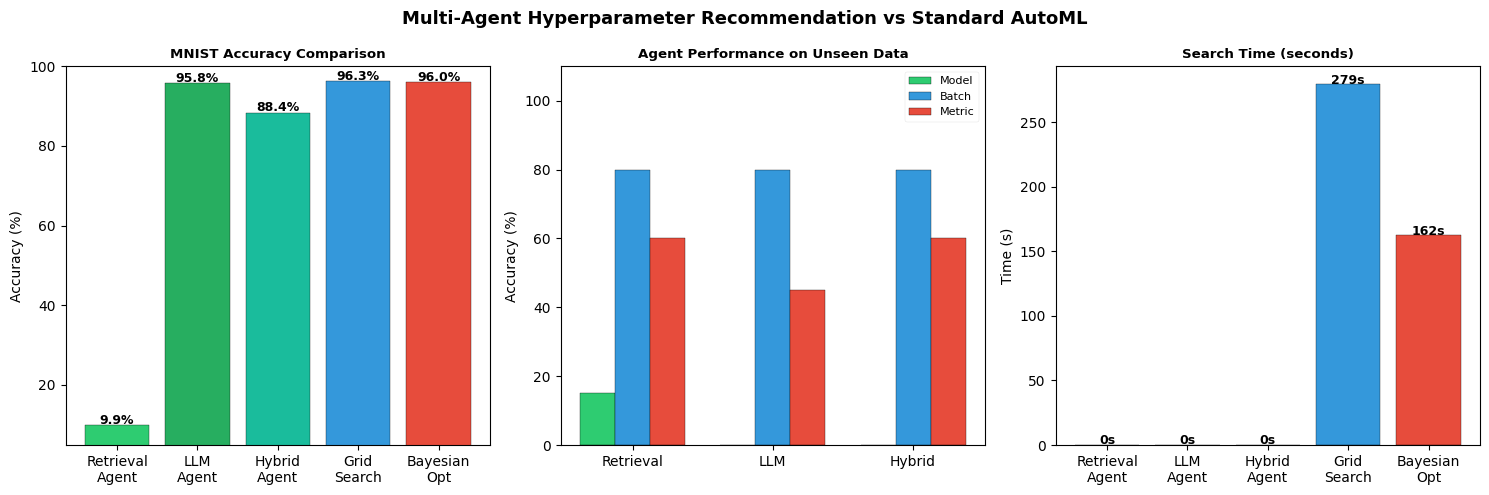

✓ Figures saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))plt.style.use('seaborn-v0_8-paper')methods = ['Retrieval\nAgent','LLM\nAgent','Hybrid\nAgent','Meta\nAgent','Grid\nSearch','Bayesian\nOpt']colors  = ['#2ecc71','#27ae60','#1abc9c','#f39c12','#3498db','#e74c3c']accs = [ret_acc, llm_acc, hyb_acc, meta_acc, grid_acc, opt_acc]bars = axes[0].bar(methods, accs, color=colors, edgecolor='black')axes[0].set_title('MNIST Accuracy Comparison', fontweight='bold')axes[0].set_ylabel('Accuracy (%)')axes[0].set_ylim(min(accs)-5, 100)for b,v in zip(bars,accs):    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')agent_names   = ['Retrieval','LLM','Hybrid','Meta']model_scores  = [df_eval['ret_model_match'].mean()*100, df_eval['llm_model_match'].mean()*100, df_eval['hyb_model_match'].mean()*100, df_eval['meta_model_match'].mean()*100]batch_scores  = [df_eval['ret_batch_match'].mean()*100, df_eval['llm_batch_match'].mean()*100, df_eval['hyb_batch_match'].mean()*100, df_eval['meta_batch_match'].mean()*100]metric_scores = [df_eval['ret_metric_match'].mean()*100, df_eval['llm_metric_match'].mean()*100, df_eval['hyb_metric_match'].mean()*100, df_eval['meta_metric_match'].mean()*100]x = np.arange(4)axes[1].bar(x-0.25, model_scores,  0.25, label='Model',  color='#2ecc71', edgecolor='black')axes[1].bar(x,      batch_scores,  0.25, label='Batch',  color='#3498db', edgecolor='black')axes[1].bar(x+0.25, metric_scores, 0.25, label='Metric', color='#e74c3c', edgecolor='black')axes[1].set_xticks(x); axes[1].set_xticklabels(agent_names)axes[1].set_title('Agent Performance on Unseen Data', fontweight='bold')axes[1].set_ylabel('Accuracy (%)')axes[1].set_ylim(0,110)axes[1].legend()times = [0, 0, 0, 0, round(grid_time,1), round(opt_time,1)]bars3 = axes[2].bar(methods, times, color=colors, edgecolor='black')axes[2].set_title('Search Time (seconds)', fontweight='bold')axes[2].set_ylabel('Time (s)')for b,v in zip(bars3,times):    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.0f}s', ha='center', fontsize=9, fontweight='bold')plt.suptitle('Multi-Agent Hyperparameter Recommendation vs Standard AutoML', fontweight='bold', fontsize=13)plt.tight_layout()plt.savefig('validation_figure.png', dpi=300, bbox_inches='tight')plt.savefig('validation_figure.pdf', bbox_inches='tight')plt.show()print('✓ Figures saved!')

In [ ]:
import pandas as pddata = {    'Agent':           ['LLM-Based', 'Hybrid', 'Retrieval-Based'],    'Seen Overall (%)':   [66.67, 57.58, 48.48],    'Unseen Overall (%)': [43.33, 46.67, 51.67],}df = pd.DataFrame(data)df['Difference (%)'] = df['Unseen Overall (%)'] - df['Seen Overall (%)']print(df.to_string(index=False))

          Agent  Seen Overall (%)  Unseen Overall (%)  Difference (%)
      LLM-Based             66.67               43.33          -23.34
         Hybrid             57.58               46.67          -10.91
Retrieval-Based             48.48               51.67            3.19


In [ ]:
import pandas as pddata = {    'Agent':              ['LLM-Based', 'Hybrid', 'Retrieval-Based', 'Meta-Learning'],    'Seen Overall (%)':   [66.67,       57.58,    48.48,             54.55],    'Unseen Overall (%)': [43.33,       46.67,    51.67,             50.00],}df = pd.DataFrame(data)df['Difference (%)'] = df['Unseen Overall (%)'] - df['Seen Overall (%)']print(df.to_string(index=False))

          Agent  Seen Overall (%)  Unseen Overall (%)  Difference (%)
      LLM-Based             66.67               43.33          -23.34
         Hybrid             57.58               46.67          -10.91
Retrieval-Based             48.48               51.67            3.19
  Meta-Learning             54.55               50.00           -4.55


In [ ]:
import pandas as pddata = {    'Agent':              ['LLM-Based', 'Hybrid', 'Retrieval-Based', 'Meta-Learning'],    'Seen Overall (%)':   [66.67,       57.58,    48.48,             54.55],    'Unseen Overall (%)': [43.33,       46.67,    51.67,             50.00],}df = pd.DataFrame(data)df['Difference (%)'] = df['Seen Overall (%)'] - df['Unseen Overall (%)']print(df.to_string(index=False))

          Agent  Seen Overall (%)  Unseen Overall (%)  Difference (%)
      LLM-Based             66.67               43.33           23.34
         Hybrid             57.58               46.67           10.91
Retrieval-Based             48.48               51.67           -3.19
  Meta-Learning             54.55               50.00            4.55
